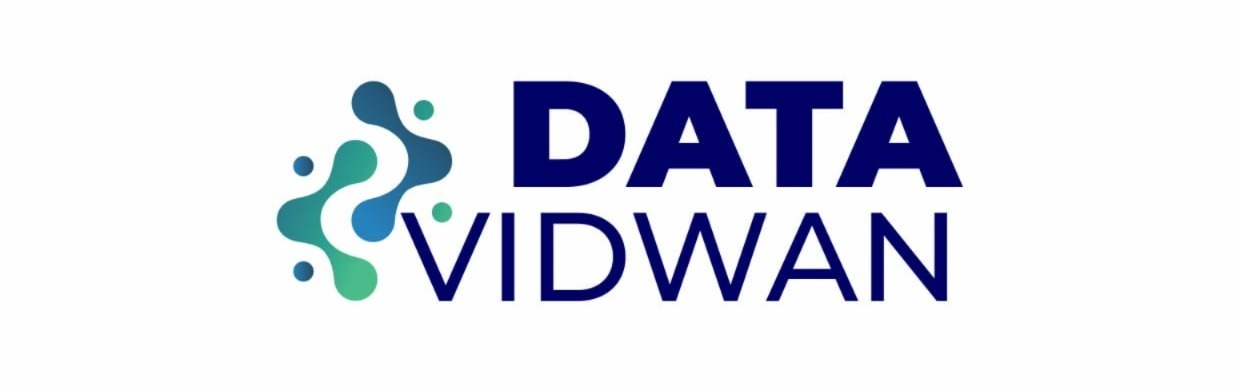

# **Polynomial Regression**

- Polynomial Regression is a type of regression analysis in which the relationship between the independent variable 𝑥 and the dependent variable y is modeled as an n-th degree polynomial.
- While Linear Regression fits a straight line, Polynomial Regression fits a curved line that can better capture the underlying trend in the data.

The general form of the polynomial regression equation is:

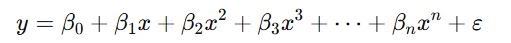

Where,
- y = Dependent variable (target)
- x = Independent variable (feature)
- 𝛽0, 𝛽1, 𝛽2,...,𝛽n = Coefficients (parameters)
- 𝜀 = Error term

Here, instead of using only x, we create new features:
[x, x2, x3]

Polynomial Regression still uses Linear Regression concepts internally; it is linear in the parameters 𝛽 but non-linear in the variable x.

**Example of Transformation**

| Original Feature (x) | Polynomial Features (degree = 3) |
| -------------------- | -------------------------------- |
| 2                    | [2, 4, 8]                        |
| 4                    | [4, 16, 64]                      |
| 5                    | [5, 25, 125]                     |

These transformations allow the model to fit curves (parabolic, cubic, etc.) instead of straight lines.

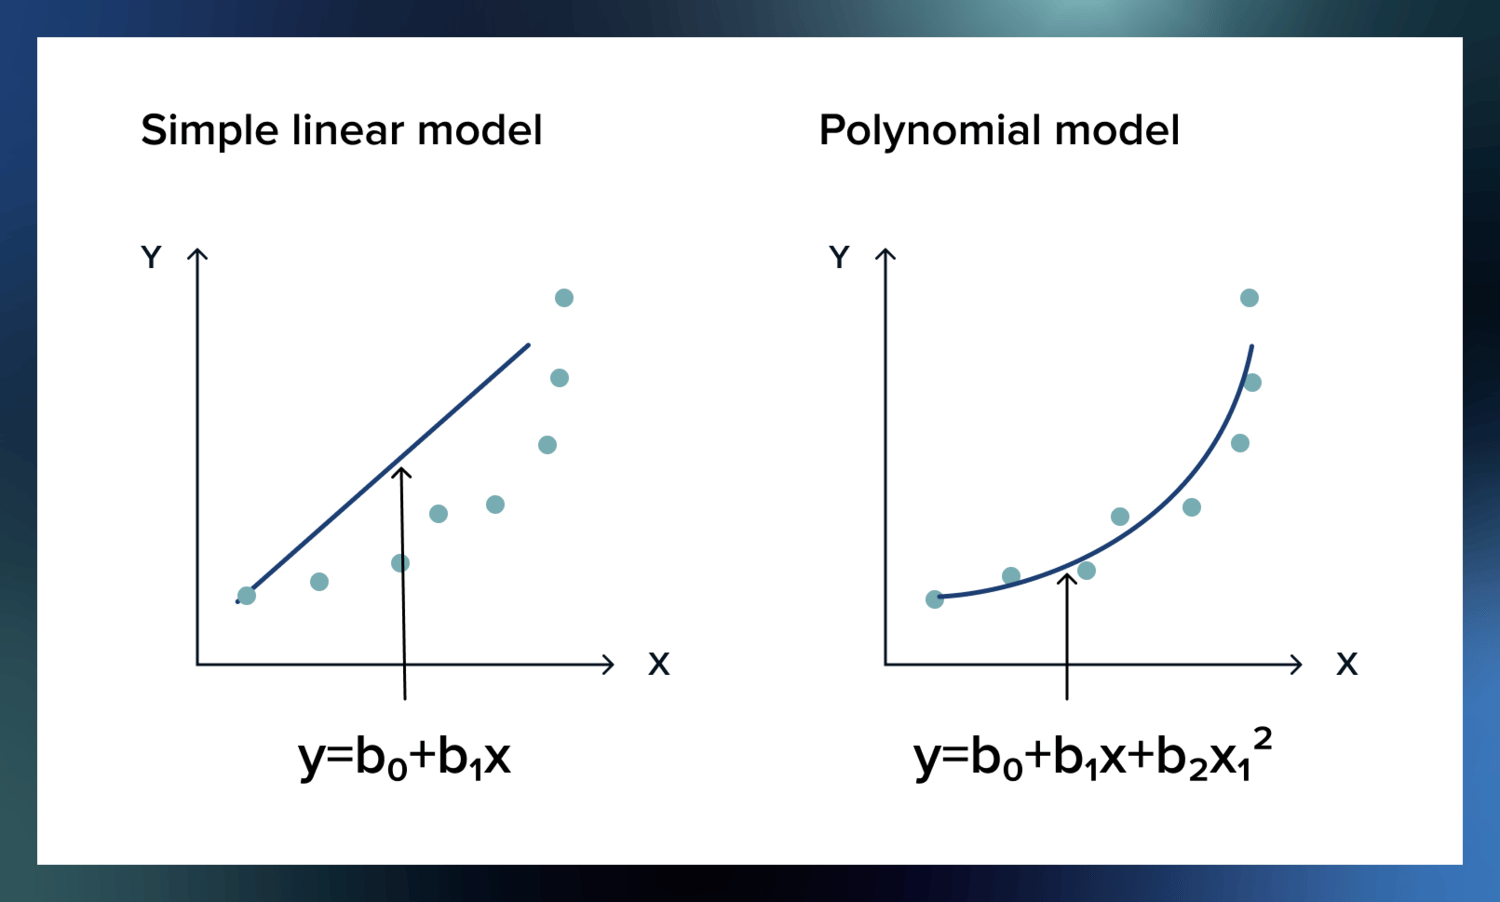

**Objective**

The main goal of Polynomial Regression is to:
- Minimize the difference between the predicted and actual values by finding optimal values of the coefficients.

**When to Use Polynomial Regression**

- The data shows a curved or non-linear trend that cannot be captured by a straight line.
- The relationship between the variables changes rate - i.e., increases or decreases at different speeds.

**Choosing the Degree of the Polynomial**

The degree of the polynomial (n) determines the flexibility of the curve:
- Low degree (1 or 2): Produces a simple curve (may underfit)
- High degree (5 or more): Produces a very flexible curve (may overfit)

Selecting the right degree is crucial - too low or too high can lead to poor performance. This balance is described by the Bias-Variance Tradeoff.

| Degree | Type of Fit   | Characteristics                             |
| ------ | ------------- | ------------------------------------------- |
| 1      | Linear        | Straight line, simplest model               |
| 2      | Quadratic     | U-shape or inverted U-shape                 |
| 3      | Cubic         | S-shaped curve                              |
| 4+     | Complex curve | Highly flexible, can capture multiple bends |




**Bias–Variance Tradeoff**

| Term         | Meaning                                                | Effect                           |
| ------------ | ------------------------------------------------------ | -------------------------------- |
| **Bias**     | Error due to oversimplification of model               | High bias causes underfitting    |
| **Variance** | Error due to sensitivity to small fluctuations in data | High variance causes overfitting |

Polynomial degree directly controls this tradeoff:

| Degree         | Bias     | Variance | Model Type   |
| -------------- | -------- | -------- | ------------ |
| Low (1)        | High     | Low      | Underfitting |
| Moderate (2–3) | Balanced | Balanced | Good fit     |
| High (5+)      | Low      | High     | Overfitting  |


**Underfitting(Low Degree)**

- The curve is too simple.
- It cannot capture the true pattern of the data.
- Both training and testing errors are high.

Visually: The line passes far away from many points.

Underfit: High Bias, Low Variance

**Solution**
- Increase the degree of the polynomial (make the model more flexible)

**Good Fit (Optimal Degree)**

- The model captures the data pattern accurately.
- Low bias and low variance.
- Performs well on both training and testing data.

Visually: The curve follows the main data trend smoothly.

Balanced Bias & Variance

**Overfitting(High Degree)**

- The model becomes too flexible.
- It starts fitting even random noise.
- Performs well on training data but poorly on new data.

Visually: The curve oscillates and bends excessively.

Overfit: Low Bias, High Variance

**Solution:**
- Reduce the degree of the polynomial
- Use regularization techniques such as Ridge or Lasso Regression
- Use cross-validation to select the best degree

## Problem Statement

The goal of this project is to analyze the non-linear relationship between a single input variable (x) and an output variable (y) using Polynomial Regression. The dataset contains numerical values where the output y changes in a curved pattern as x increases or decreases. The task is to fit an appropriate polynomial model that can learn this relationship and accurately predict y for any given x.

**Import Libraries**

In [1]:
# Step 1 — Import Libraries
import pandas as pd                # for data handling
import numpy as np                 # for numerical operations
import matplotlib.pyplot as plt    # for visualization
import seaborn as sns              # for better visual styling

from sklearn.model_selection import train_test_split   # for splitting data
from sklearn.preprocessing import PolynomialFeatures, StandardScaler  # to create polynomial terms & scale data
from sklearn.pipeline import Pipeline                  # to combine steps
from sklearn.linear_model import LinearRegression       # base model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # evaluation metrics

**Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving PolynomialRegression_Large.csv to PolynomialRegression_Large.csv


In [3]:
df = pd.read_csv("PolynomialRegression_Large.csv")
df.head()

,x,y
0,-3.763796,-10.866799
1,13.521429,232.183931
2,6.959818,199.879636
3,2.959755,119.276737
4,-10.319441,-285.678243


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1800 non-null   float64
 1   y       1800 non-null   float64
dtypes: float64(2)
memory usage: 28.3 KB


,0
x,0
y,0


**Split Dataset into Train and Test Sets**

In [6]:
# Step 2 — Split data into train and test sets

# Select features (independent variable) and target (dependent variable)
X = df[["x"]]   # feature
y = df["y"]     # target

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1440, 1)
Testing data shape: (360, 1)


**Build the Polynomial Regression pipeline**

In [8]:
# Step 3 - Build the Polynomial Regression pipeline

# choose the polynomial degree (start with 3; you can change later)
degree = 3

poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

print("Pipeline created with degree =", degree)

Pipeline created with degree = 3


**Train / Fit the Pipeline**

In [9]:
# Step 4 — Train (fit) the polynomial regression pipeline
poly_pipe.fit(X_train, y_train)

# Inspect generated polynomial features (for clarity)
feature_names = poly_pipe.named_steps['poly'].get_feature_names_out(['x'])
print("Number of features created:", len(feature_names))
print("Feature names:", feature_names.tolist())

Number of features created: 3
Feature names: ['x', 'x^2', 'x^3']


**Predict on Test Set & Evaluate Performance**

In [10]:
# Step 5 — Predict & Evaluate

# Predict on test set
y_pred = poly_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print evaluation metrics
print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:,.2f}")
print(f"MSE       : {mse:,.2f}")
print(f"RMSE      : {rmse:,.2f}")

R² Score  : 0.9883
MAE       : 20.02
MSE       : 673.87
RMSE      : 25.96


**Visualization: Actual vs Predicted Curve**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


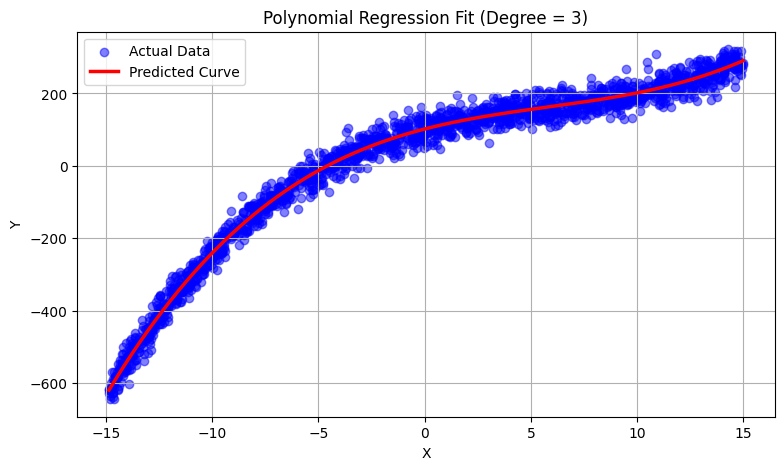

In [11]:
# Step 6 — Visualization: Actual vs Predicted Curve

# Create a smooth range of x values for plotting the fitted curve
x_line = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

# Predict using the trained model
y_line = poly_pipe.predict(x_line)

# Plot
plt.figure(figsize=(9,5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(x_line, y_line, color='red', linewidth=2.5, label='Predicted Curve')
plt.title("Polynomial Regression Fit (Degree = 3)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

- The blue scatter points show the original data.
- The red curve shows how the model has fit the trend.
- If the curve closely follows the data, the model is performing well.

**Before vs After Prediction**

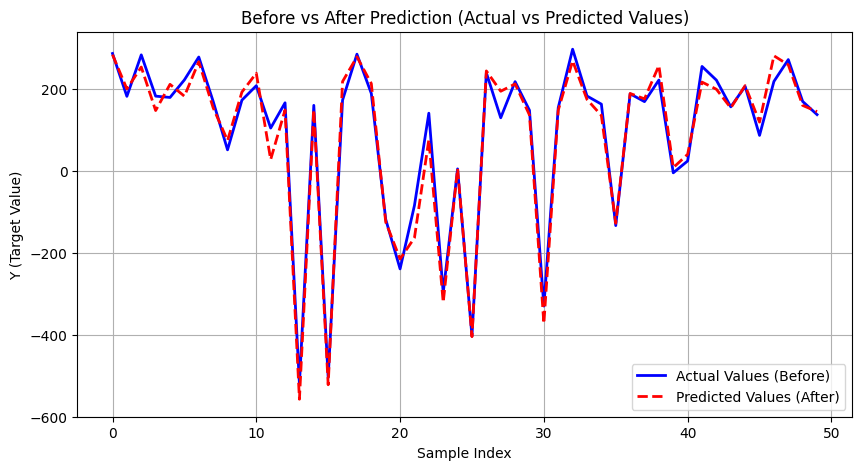

In [12]:
# Step 7 — Before vs After Prediction (Line Plot)

plt.figure(figsize=(10,5))

# Plot first 50 samples for clear comparison
plt.plot(y_test.values[:50], label='Actual Values (Before)', color='blue', linewidth=2)
plt.plot(y_pred[:50], label='Predicted Values (After)', color='red', linestyle='--', linewidth=2)

plt.title("Before vs After Prediction (Actual vs Predicted Values)")
plt.xlabel("Sample Index")
plt.ylabel("Y (Target Value)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Step 8 — Save the trained model

import pickle

# Save the entire pipeline
with open("PolynomialRegression_Model.pkl", "wb") as file:
    pickle.dump(poly_pipe, file)

print("Model saved successfully as 'PolynomialRegression_Model.pkl'")

Model saved successfully as 'PolynomialRegression_Model.pkl'
